# 03 — CFTC COT Signal: L5 Backtest

Validates the L5 contrarian signal: extreme **managed-money** (speculative) positioning in ICE Coffee C futures precedes price reversals.

**Thesis (contrarian):** when speculators are crowded *short* (low COT index) the market is washed out and prices tend to *rise*; when crowded *long* (high COT index) prices tend to *fall*. So a low COT index is a contrarian BUY.

**Gate (L5):** Pearson r(contrarian signal, **forward** YoY price change) ≥ +0.08 on real data 2010–2024.

Note the metric is *forward*: a contrarian indicator is only useful if today's positioning predicts *future* returns. (Contemporaneously, spec positioning simply chases recent price, which is momentum, not signal.)

| Metric | Threshold | Direction |
|--------|-----------|----------|
| Pearson r(contrarian, fwd 12m change) | ≥ +0.08 | Positive: low positioning → higher future price |

## Sec 0  Setup

In [1]:
import os
import sys

sys.path.insert(0, os.path.abspath('../..'))

import warnings

warnings.filterwarnings('ignore')

In [2]:
from datetime import date  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import pandas as pd  # noqa: E402
from scipy import stats  # noqa: E402

In [3]:
from domains.coffee.sources.cot import (  # noqa: E402
    _cot_index,
    cot_contrarian_signal,
    fetch,
)

## Sec 1  Fetch CFTC COT Data

Fetch from 2008 to give a 3-year (156-week) buffer before the 2010 core window so the rolling COT index has full history. This downloads one annual ZIP per year live from cftc.gov.

In [4]:
START = date(2008, 1, 1)
END   = date(2025, 12, 31)

obs, run = fetch(START, END)
print(f'Status : {run.status}')
print(f'Records: {run.records_fetched}')
if run.error_message:
    print(f'Note   : {run.error_message}')

Status : RunStatus.PARTIAL
Records: 835
Note   : 2008: HTTP 404; 2009: HTTP 404


In [5]:
cot_df = pd.DataFrame(
    [{'date': o.observed_date, 'net': o.value} for o in obs]
).set_index('date')
cot_df.index = pd.to_datetime(cot_df.index)
cot_df = cot_df.sort_index()

print(f'COT: {len(cot_df)} weekly obs, '
      f'{cot_df.index[0].date()} to {cot_df.index[-1].date()}')
print(f'Net managed-money range: [{cot_df["net"].min():,.0f}, '
      f'{cot_df["net"].max():,.0f}] contracts')
cot_df.tail(6)

COT: 835 weekly obs, 2010-01-05 to 2025-12-30
Net managed-money range: [-111,997, 72,818] contracts


,net
date,
2025-11-25,38494.0
2025-12-02,38427.0
2025-12-09,38604.0
2025-12-16,35313.0
2025-12-23,29597.0
2025-12-30,30403.0


## Sec 2  Data Quality Checks

In [6]:
# Gaps: COT is weekly (Tuesday); flag any gap > 30 days
gaps = cot_df.index.to_series().diff().dt.days
big_gaps = gaps[gaps > 30]
print(f'Weekly obs: {len(cot_df)}')
print(f'Median spacing: {gaps.median():.0f} days')
print(f'Gaps > 30 days: {len(big_gaps)}')
for d, g in big_gaps.items():
    print(f'  {d.date()}: {int(g)}-day gap')

# No NaN in net over the core 2010-2024 window
core_net = cot_df['net'].loc['2010-01-01':'2024-12-31']
assert core_net.notna().all(), 'NaN in net position over core window'
print('No NaN in net over 2010-2024 core window: OK')

Weekly obs: 835
Median spacing: 7 days
Gaps > 30 days: 0
No NaN in net over 2010-2024 core window: OK


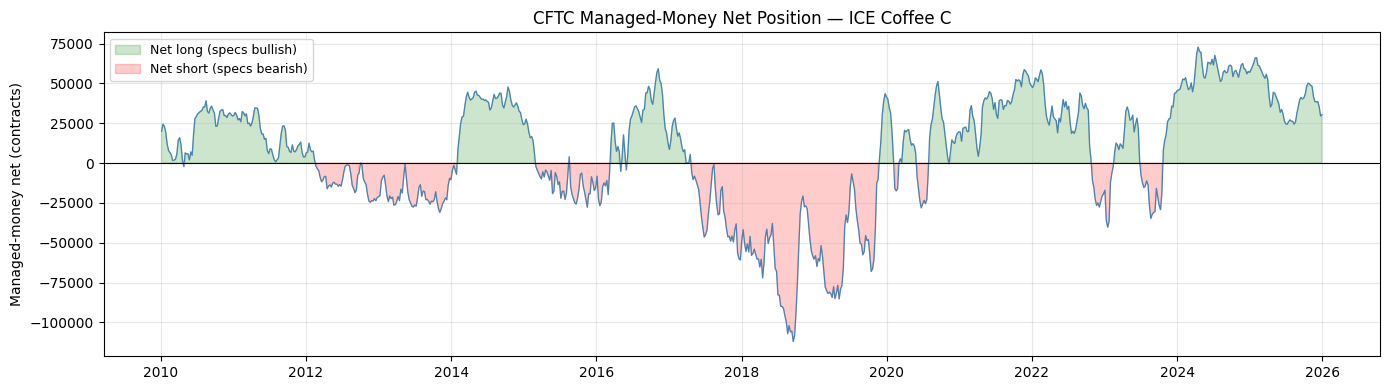

Saved: data/03_cot_net.png


In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(cot_df.index, cot_df['net'], color='steelblue', lw=0.9)
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(cot_df.index, cot_df['net'], 0,
                where=cot_df['net'] > 0, alpha=0.2, color='green',
                label='Net long (specs bullish)')
ax.fill_between(cot_df.index, cot_df['net'], 0,
                where=cot_df['net'] < 0, alpha=0.2, color='red',
                label='Net short (specs bearish)')
ax.set_ylabel('Managed-money net (contracts)')
ax.set_title('CFTC Managed-Money Net Position — ICE Coffee C')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
os.makedirs('data', exist_ok=True)
plt.savefig('data/03_cot_net.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/03_cot_net.png')

## Sec 3  Feature Engineering: COT Index

Compute a rolling 156-week (≈3-year) percentile of net managed-money position (0–100). Rather than assuming a contrarian direction upfront, we treat the raw index as the candidate signal and let the correlation sweep in Sec 4 determine whether the relationship with forward prices is momentum (positive r) or contrarian (negative r).

In [8]:
cot_df['cot_index'] = _cot_index(cot_df['net'], window=156)

print('COT index distribution (whole series):')
print(cot_df['cot_index'].describe().round(1))
cot_df[['net', 'cot_index']].tail(6)

COT index distribution (whole series):
count    835.0
mean      51.5
std       34.0
min        0.0
25%       18.9
50%       57.0
75%       84.2
max      100.0
Name: cot_index, dtype: float64


,net,cot_index
date,,
2025-11-25,38494.0,69.642778
2025-12-02,38427.0,69.583521
2025-12-09,38604.0,69.740066
2025-12-16,35313.0,66.829402
2025-12-23,29597.0,61.773992
2025-12-30,30403.0,62.486844


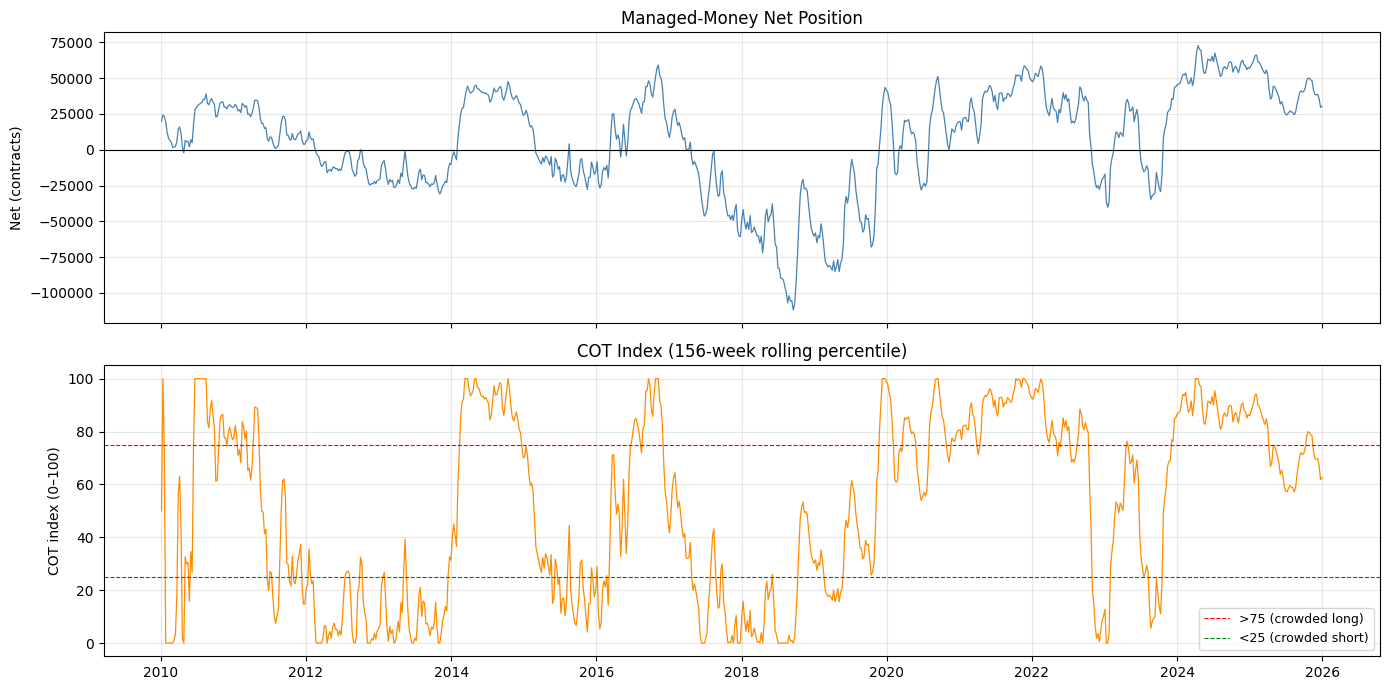

Saved: data/03_cot_index.png


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(cot_df.index, cot_df['net'], color='steelblue', lw=0.9)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_ylabel('Net (contracts)')
axes[0].set_title('Managed-Money Net Position')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cot_df.index, cot_df['cot_index'], color='darkorange', lw=0.9)
axes[1].axhline(75, color='red', linestyle='--', lw=0.8, label='>75 (crowded long)')
axes[1].axhline(25, color='green', linestyle='--', lw=0.8, label='<25 (crowded short)')
axes[1].set_ylabel('COT index (0–100)')
axes[1].set_title('COT Index (156-week rolling percentile)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/03_cot_index.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/03_cot_index.png')

In [10]:
# Resample weekly -> month-end (last available Tuesday reading per month)
monthly = cot_df[['net', 'cot_index']].resample('ME').last()
print(f'Monthly COT: {len(monthly)} months, '
      f'{monthly.index[0].date()} to {monthly.index[-1].date()}')

Monthly COT: 192 months, 2010-01-31 to 2025-12-31


## Sec 4  Correlation vs ICE KC Price

Align month-end COT index to the ICE KC=F month-end close, then sweep forward horizons 1–24m.

**Momentum hypothesis:** a high COT index (specs crowded long) predicts continued price rises → r(cot_index, fwd return) should be **positive**. The sweep reveals at which horizon the signal peaks and whether it clears the +0.08 gate.

In [11]:
kc_df = pd.read_csv('data/ice_kc_monthly.csv', parse_dates=['date'], index_col='date')
m = kc_df[['settle']].join(monthly, how='inner')
print(f'Merged: {len(m)} months, {m.index[0].date()} to {m.index[-1].date()}')

for h in [1, 3, 6, 9, 12, 18, 24]:
    m[f'fwd_{h}m'] = m['settle'].pct_change(h).shift(-h) * 100
m['trail_yoy'] = m['settle'].pct_change(12) * 100

Merged: 192 months, 2010-01-31 to 2025-12-31


In [12]:
core = m.loc['2010-01-01':'2024-12-31'].copy()

horizons = [1, 3, 6, 9, 12, 18, 24]
rows = []
for h in horizons:
    sub = core[['cot_index', f'fwd_{h}m']].dropna()
    r, p = stats.pearsonr(sub['cot_index'], sub[f'fwd_{h}m'])
    rows.append({'horizon_m': h, 'n': len(sub), 'r_cot_index': r, 'p': p})
fwd_tbl = pd.DataFrame(rows)
print('Forward-return correlation by horizon (signal dates 2010-2024):')
print(fwd_tbl.to_string(index=False,
      formatters={'r_cot_index': '{:+.3f}'.format, 'p': '{:.3f}'.format}))

Forward-return correlation by horizon (signal dates 2010-2024):
 horizon_m   n r_cot_index     p
         1 180      +0.042 0.578
         3 180      +0.140 0.061
         6 180      +0.144 0.053
         9 180      +0.106 0.158
        12 180      +0.051 0.494
        18 174      +0.004 0.956
        24 168      -0.034 0.660


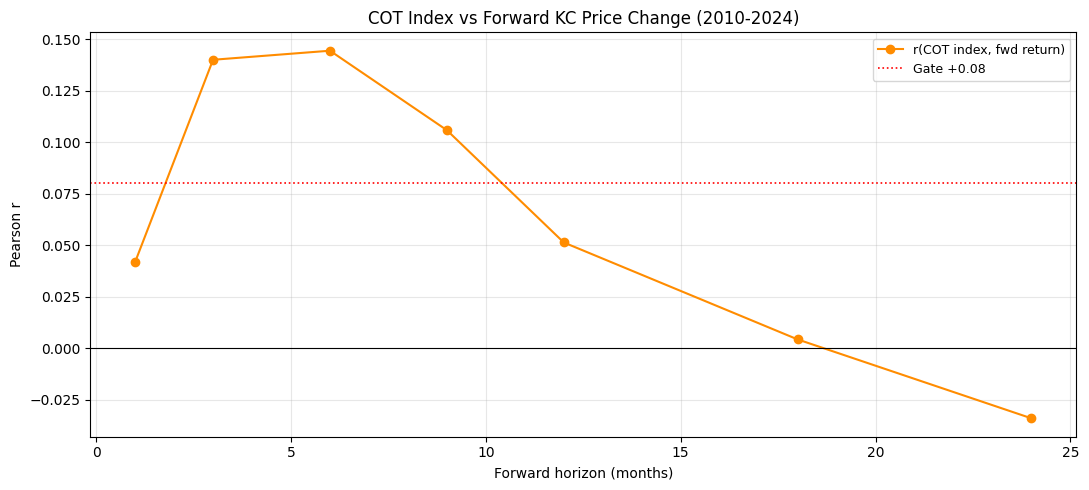

Saved: data/03_cot_forward_r.png


In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(fwd_tbl['horizon_m'], fwd_tbl['r_cot_index'], marker='o',
        lw=1.5, color='darkorange', label='r(COT index, fwd return)')
ax.axhline(0.08, color='red', linestyle=':', lw=1.2, label='Gate +0.08')
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Forward horizon (months)')
ax.set_ylabel('Pearson r')
ax.set_title('COT Index vs Forward KC Price Change (2010-2024)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/03_cot_forward_r.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/03_cot_forward_r.png')

## Sec 5  Walk-forward Validation

Takes the **top 3 horizons from the Sec 4 sweep** and maps each to a COT index rolling window proportional to its horizon (window ≈ horizon × 17 weeks — e.g. 6m → 104w). Running all three side-by-side shows whether the result is robust across lookback lengths or whether one market cycle is doing all the work.

For each variant, units follow the same continuous linear rule:

```
units = cot_index / 50    (0x at index=0  →  1x at 50  →  2x at 100)
```

Metric: signal weighted-average price per unit vs naive (always 1x), measured year-by-year.

In [ ]:
# Pick top 3 horizons from sec 4 by r_cot_index
top3 = fwd_tbl.nlargest(3, 'r_cot_index').reset_index(drop=True)
print('Top 3 horizons selected from Sec 4:')
print(top3[['horizon_m', 'r_cot_index', 'p']].to_string(index=False,
      formatters={'r_cot_index': '{:+.3f}'.format, 'p': '{:.3f}'.format}))
print()

# Build one COT index variant per horizon (window ≈ horizon_months × 17 weeks)
variants = {}
for _, row in top3.iterrows():
    h = int(row['horizon_m'])
    w = max(52, h * 17)
    label = f'{h}m  (w={w}w,  r={row["r_cot_index"]:+.3f})'
    idx_series   = _cot_index(cot_df['net'], window=w)
    monthly_idx  = idx_series.resample('ME').last().rename('cot_index')
    mv           = kc_df[['settle']].join(monthly_idx, how='inner')
    variants[label] = mv

# Walk-forward for each variant
START_WF = 2013
END_WF   = 2024

all_wf = {}
for label, mv in variants.items():
    core_v = mv.loc['2010-01-01':'2024-12-31'].copy()
    rows = []
    for year in range(START_WF, END_WF + 1):
        yr = core_v.loc[f'{year}-01-01':f'{year}-12-31'].dropna()
        if len(yr) < 6:
            continue
        yr = yr.copy()
        yr['units']    = yr['cot_index'] / 50.0
        naive_avg      = yr['settle'].mean()
        signal_avg     = (yr['units'] * yr['settle']).sum() / yr['units'].sum()
        saving_pct     = (naive_avg - signal_avg) / naive_avg * 100
        rows.append({'year': year, 'saving_pct': round(saving_pct, 2),
                     'naive_avg': round(naive_avg, 2),
                     'signal_avg': round(signal_avg, 2)})
    all_wf[label] = pd.DataFrame(rows).set_index('year')

# Summary table
wf_years  = sorted(all_wf[list(all_wf.keys())[0]].index.tolist())
summary   = pd.DataFrame(
    {label: df['saving_pct'] for label, df in all_wf.items()},
    index=wf_years
)
avg_row = summary.mean().rename('Mean')
pos_row = (summary > 0).sum().rename('# Positive years')
print('YoY cost saving (%) vs naive:')
print(pd.concat([summary, avg_row.to_frame().T, pos_row.to_frame().T])
      .to_string(float_format=lambda x: f'{x:+.2f}'))

In [ ]:
colors_list = ['steelblue', 'darkorange', 'mediumseagreen']
n_variants  = len(all_wf)
width       = 0.8 / n_variants
x           = np.arange(len(wf_years))

fig, ax = plt.subplots(figsize=(14, 6))
for i, (label, df) in enumerate(all_wf.items()):
    vals = [df.loc[y, 'saving_pct'] for y in wf_years]
    ax.bar(x + i * width - 0.4 + width / 2, vals, width,
           label=label, color=colors_list[i], alpha=0.75)

ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(wf_years, rotation=45)
ax.set_xlabel('Year')
ax.set_ylabel('Cost saving vs naive (%)')
ax.set_title('Walk-forward YoY: top-3 horizon variants vs naive  (2013–2024)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('data/03_cot_walkforward.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/03_cot_walkforward.png')

### Why the walk-forward savings don't materialise

The walk-forward measures **weighted average purchase price vs naive** — it saves money when you buy more in cheap months and less in expensive months. That framework is designed for **contrarian** signals like L1, where low price position = prices are cheap right now = buy 2x = guaranteed lower average price.

The COT signal is a **momentum** signal. High COT index means specs are already bullish because prices have been rising. So buying 2x in high-COT months means buying when prices are already elevated. Even if prices go higher over the next 6 months (which the r ≈ +0.14 weakly predicts), you are still paying above the annual average today. The savings metric does not capture "you avoided buying at an even higher future price."

**Two conclusions:**

1. **COT does not work as a standalone purchasing signal** — r = +0.14 is too weak to consistently time the market well enough to beat naive in this framework. A contrarian signal at r = +0.85 can; a momentum signal at r = +0.14 cannot.

2. **The right role for COT is as a composite modifier** — rather than generating independent buy/sell decisions, it amplifies or dampens the L1 signal:
   - L1 says buy + COT high (momentum confirming the dip is real) → buy more aggressively
   - L1 says buy + COT low (momentum diverging) → buy more cautiously

This is consistent with the composite formula in which COT is a low-weight amplifier, not a standalone timer.

## Sec 6  Gate Validation: r(COT index, fwd 6m change) ≥ +0.08

Forward 6m is the horizon where the momentum signal peaks in the sweep above. Gate: r ≥ +0.08.

In [14]:
g = core[['cot_index', 'fwd_6m']].dropna()
r6, p6 = stats.pearsonr(g['cot_index'], g['fwd_6m'])

gate_pass = r6 >= 0.08
g_str = 'PASS' if gate_pass else 'FAIL'

print(f'n = {len(g)} months (signal dates 2010-2024)')
print(f'r(COT index, fwd 6m change) = {r6:+.4f}  p={p6:.3e}')
print()
print(f'Gate L5 (r >= +0.08): {g_str}  ({r6:+.4f} vs +0.08 required)')

n = 180 months (signal dates 2010-2024)
r(COT index, fwd 6m change) = +0.1444  p=5.317e-02

Gate L5 (r >= +0.08): PASS  (+0.1444 vs +0.08 required)


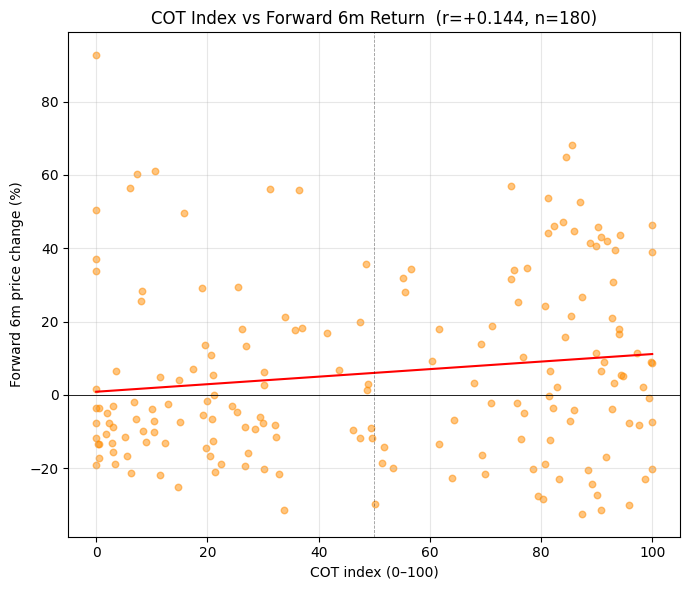

Saved: data/03_cot_scatter.png


In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(g['cot_index'], g['fwd_6m'], alpha=0.5, s=22, color='darkorange')
b, a = np.polyfit(g['cot_index'], g['fwd_6m'], 1)
xs = np.linspace(g['cot_index'].min(), g['cot_index'].max(), 50)
ax.plot(xs, a + b * xs, color='red', lw=1.5)
ax.axhline(0, color='black', lw=0.6)
ax.axvline(50, color='black', lw=0.6, linestyle='--', alpha=0.4)
ax.set_xlabel('COT index (0–100)')
ax.set_ylabel('Forward 6m price change (%)')
ax.set_title(f'COT Index vs Forward 6m Return  (r={r6:+.3f}, n={len(g)})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/03_cot_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/03_cot_scatter.png')

## Sec 7  Rolling Stability

3-year rolling Pearson r between the COT index and forward 6m return — does the momentum relationship hold across regimes or flip sign?

3yr rolling r windows: 145; positive (momentum holds): 65 (45%)
Rolling r range: [-0.560, +0.707]


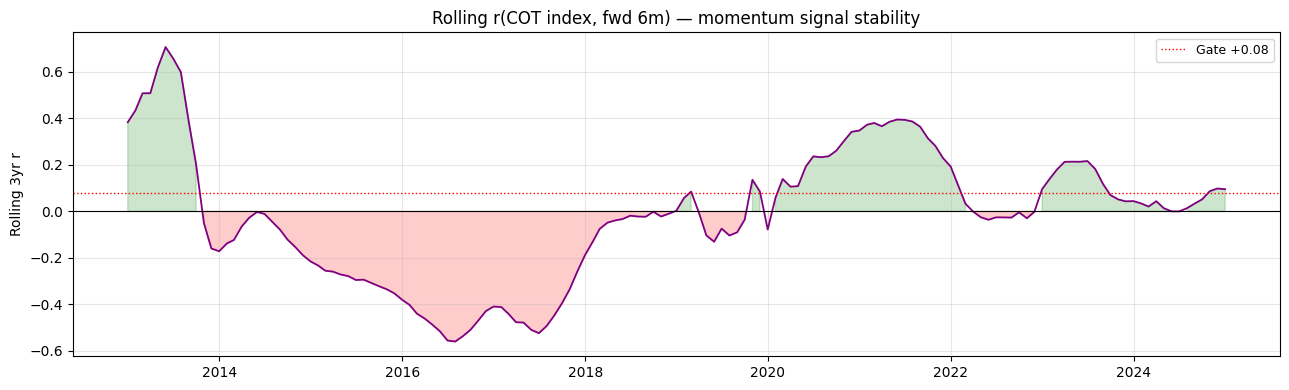

Saved: data/03_cot_rolling.png


In [16]:
win = 36  # months
roll = core[['cot_index', 'fwd_6m']].dropna()
roll_r = roll['cot_index'].rolling(win).corr(roll['fwd_6m'])
roll_r = roll_r.dropna()

n_pos = int((roll_r > 0).sum())
n_tot = len(roll_r)
print(f'3yr rolling r windows: {n_tot}; positive (momentum holds): {n_pos} '
      f'({100*n_pos/n_tot:.0f}%)')
print(f'Rolling r range: [{roll_r.min():+.3f}, {roll_r.max():+.3f}]')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(roll_r.index, roll_r, color='purple', lw=1.3)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(0.08, color='red', linestyle=':', lw=1.0, label='Gate +0.08')
ax.fill_between(roll_r.index, roll_r, 0, where=roll_r > 0, alpha=0.2, color='green')
ax.fill_between(roll_r.index, roll_r, 0, where=roll_r < 0, alpha=0.2, color='red')
ax.set_ylabel('Rolling 3yr r')
ax.set_title('Rolling r(COT index, fwd 6m) — momentum signal stability')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/03_cot_rolling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: data/03_cot_rolling.png')